# [CIE 5158] Dynamic World V1 — GEE to COG Pipeline

> **Dataset:** [Dynamic World V1](https://developers.google.com/earth-engine/datasets/catalog/GOOGLE_DYNAMICWORLD_V1) — near real-time (NRT) global land use / land cover classification at 10 m resolution, generated from Sentinel-2 imagery by Google.

| Step | Description |
| :--- | :--- |
| **1. Read Example Dataset** | Access Dynamic World V1 via GEE, load all KuroSiwo event AOIs and timestamps, and visualize a preview composite |
| **2. Export to Cloud-Optimized GeoTIFF** | Convert event-month mosaics to self-describing, range-request-friendly COG files; derive exact spatial and temporal extent from the exports |

---
**Study area:** All KuroSiwo event bounding boxes from `kurosiwo_bboxes_4326.csv`  
**Time range:** Event-specific monthly windows derived from `kurosiwo_times_revised.csv`

In [ ]:
# uv pip install rioxarray earthengine-api xee requests rich
#
# OR without uv:
# pip install rioxarray earthengine-api xee requests rich

In [ ]:
import io
import json
import zipfile
from datetime import datetime, timezone
from pathlib import Path

import ee
import numpy as np
import pandas as pd
import requests
import rasterio
import xarray
import rioxarray  # noqa: F401 - registers .rio accessor on xarray
from rasterio.shutil import copy as rio_copy

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

from rich import print as rprint
from rich.panel import Panel
from rich.table import Table

---
## 1. Read Dynamic World Data from Google Earth Engine

Google Earth Engine (GEE) hosts Dynamic World V2 as an `ImageCollection`. Each `Image` in the collection represents one Sentinel-2 scene classified with a ten-class model at 10 m resolution. In this section we:

1. Authenticate with a service-account key
2. Load all KuroSiwo event AOIs and timestamps from the CSV inputs
3. Select one event with Dynamic World coverage for preview and band inspection
4. Load an event-month mosaic via `xee` and visualize the classification map

### 1.1 GEE Service Account Authentication

In [3]:
SERVICE_ACCOUNT = "danliu-gee@big-dara.iam.gserviceaccount.com"
KEY_PATH        = "./big-dara-45723c65fd60.json"

credentials = ee.ServiceAccountCredentials(SERVICE_ACCOUNT, KEY_PATH)
ee.Initialize(credentials)
rprint(Panel("[green]GEE initialized successfully[/green]", expand=False))

╭──────────────────────────────╮
│ GEE initialized successfully │
╰──────────────────────────────╯

### 1.2 Dynamic World V2 — Dataset Description

| Property | Value |
| :--- | :--- |
| **GEE collection ID** | `GOOGLE/DYNAMICWORLD/V1` |
| **Native resolution** | 10 m (Sentinel-2 pixel grid) |
| **Projection** | UTM (per Sentinel-2 tile) → we reproject to EPSG:4326 on export |
| **Temporal coverage** | 2015-06-23 → present (near-real-time, ~5-day revisit) |
| **Band count** | 10  (9 class-probability bands + 1 label band) |

#### Class Legend

| Index | Class | Colour |
| :--- | :--- | :--- |
| 0 | Water | `#419BDF` |
| 1 | Trees | `#397D49` |
| 2 | Grass | `#88B053` |
| 3 | Flooded Vegetation | `#7A87C6` |
| 4 | Crops | `#E49635` |
| 5 | Shrub & Scrub | `#DFC35A` |
| 6 | Built Area | `#C4281B` |
| 7 | Bare Ground | `#A59B8F` |
| 8 | Snow & Ice | `#B39FE1` |

> The `label` band holds the **index (0–8) of the highest-probability class** for each pixel.

In [4]:
# ── Study areas and annual windows from KuroSiwo event CSVs ───────
BBOXES_CSV = Path("kurosiwo_bboxes_4326.csv")
TIMES_CSV = Path("kurosiwo_times_revised.csv")
DW_DATASET_START = pd.Timestamp("2015-06-27", tz="UTC")


def month_start(timestamp: pd.Timestamp) -> pd.Timestamp:
    return pd.Timestamp(
        year=int(timestamp.year),
        month=int(timestamp.month),
        day=1,
        tz="UTC",
    )


def next_month_start(timestamp: pd.Timestamp) -> pd.Timestamp:
    return timestamp + pd.offsets.MonthBegin(1)


def build_dw_collection(event: dict[str, object], start_date: str | None = None, end_date: str | None = None):
    return (
        ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
        .filterBounds(event["geometry"] )
        .filterDate(start_date or event["window_start"], end_date or event["window_end"] )
    )


bboxes_df = pd.read_csv(BBOXES_CSV, dtype={"filename": str})
times_df = pd.read_csv(TIMES_CSV, dtype={"filename": str})

times_long = (
    times_df.melt(id_vars="filename", value_vars=["time1", "time2"], value_name="timestamp")
    .dropna(subset=["timestamp"] )
    .assign(timestamp=lambda df: pd.to_datetime(df["timestamp"], utc=True))
    .sort_values(["filename", "timestamp"] )
    [["filename", "timestamp"]]
 )

event_times = times_long.groupby("filename")["timestamp"].agg(list)

EVENTS: dict[str, dict[str, object]] = {}
skipped_pre_dw: list[str] = []

for row in bboxes_df.itertuples(index=False):
    event_id = str(row.filename)
    timestamps = event_times.get(event_id, [])
    if not timestamps:
        continue

    raw_start = min(timestamps)
    raw_end = max(timestamps)
    if raw_end < DW_DATASET_START:
        skipped_pre_dw.append(event_id)
        continue

    bbox = [float(row.west), float(row.south), float(row.east), float(row.north)]
    geometry = ee.Geometry.BBox(*bbox)

    # Annual composite window: [event_end - 1 year, event_end] (inclusive by day).
    annual_end_exclusive = raw_end.normalize() + pd.Timedelta(days=1)
    annual_start_ts = max(annual_end_exclusive - pd.DateOffset(years=1), DW_DATASET_START.normalize())
    annual_end_inclusive = annual_end_exclusive - pd.Timedelta(seconds=1)
    interval_label = f"annual-{annual_start_ts.strftime('%Y%m%d')}-{annual_end_inclusive.strftime('%Y%m%d')}"

    intervals = [
        {
            "label": interval_label,
            "start": annual_start_ts.strftime("%Y-%m-%d"),
            "end": annual_end_exclusive.strftime("%Y-%m-%d"),
            "start_datetime": annual_start_ts,
            "end_datetime": annual_end_inclusive,
        }
    ]

    EVENTS[event_id] = {
        "event_id": event_id,
        "bbox": bbox,
        "geometry": geometry,
        "timestamps": timestamps,
        "raw_start": raw_start,
        "raw_end": raw_end,
        "window_start": annual_start_ts.strftime("%Y-%m-%d"),
        "window_end": annual_end_exclusive.strftime("%Y-%m-%d"),
        "intervals": intervals,
    }

PREVIEW_EVENT_ID = next(
    event_id
    for event_id, event in EVENTS.items()
    if build_dw_collection(event).size().getInfo() > 0
)
PREVIEW_EVENT = EVENTS[PREVIEW_EVENT_ID]
collection = build_dw_collection(PREVIEW_EVENT)
image_count = collection.size().getInfo()

AOI = PREVIEW_EVENT["geometry"]
START_DATE = PREVIEW_EVENT["window_start"]
END_DATE = PREVIEW_EVENT["window_end"]
PREVIEW_INTERVAL = PREVIEW_EVENT["intervals"][0]

bbox_text = ", ".join(f"{value:.4f}" for value in PREVIEW_EVENT["bbox"] )

rprint(Panel(
    f"[bold]Events loaded:[/bold]      {len(EVENTS)}\n"
    f"[bold]Skipped pre-DW:[/bold]     {len(skipped_pre_dw)}\n"
    f"[bold]Preview event:[/bold]      {PREVIEW_EVENT_ID}\n"
    f"[bold]Bounding box:[/bold]       {bbox_text}\n"
    f"[bold]Annual window:[/bold]      {START_DATE}  →  {END_DATE}\n"
    f"[bold]Image count:[/bold]        {image_count:,}  (preview event)",
    title="[bold]Dynamic World V1 — KuroSiwo Annual Coverage[/bold]",
    expand=False,
) )

╭───── Dynamic World V1 — KuroSiwo Annual Coverage ──────╮
│ Events loaded:      42                                 │
│ Skipped pre-DW:     1                                  │
│ Preview event:      1111002                            │
│ Bounding box:       14.7969, 12.1763, 14.9180, 12.3144 │
│ Annual window:      2019-09-16  →  2020-09-16          │
│ Image count:        46  (preview event)                │
╰────────────────────────────────────────────────────────╯

In [5]:
# ── Inspect the first image's band definitions ──────────────────
first_image = collection.first()
info = first_image.getInfo()

image_date = datetime.fromtimestamp(
    info["properties"]["system:time_start"] / 1000,
    tz=timezone.utc,
).strftime("%Y-%m-%d")

t = Table(
    title=f"First Image Bands  (event {PREVIEW_EVENT_ID}, acquired {image_date})",
    show_lines=True,
 )
t.add_column("Index",     style="cyan",   justify="right")
t.add_column("Band name", style="green")
t.add_column("Data type", style="yellow")
t.add_column("Role",      style="white")

roles = {
    "water": "class probability", "trees": "class probability",
    "grass": "class probability", "flooded_vegetation": "class probability",
    "crops": "class probability", "shrub_and_scrub": "class probability",
    "built": "class probability", "bare": "class probability",
    "snow_and_ice": "class probability", "label": "classification index",
}

for i, b in enumerate(info["bands"]):
    t.add_row(str(i), b["id"], b["data_type"]["precision"],
              roles.get(b["id"], "-"))

rprint(t)

     First Image Bands  (event 1111002, acquired 2019-10-01)     
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Index ┃ Band name          ┃ Data type ┃ Role                 ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│     0 │ water              │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     1 │ trees              │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     2 │ grass              │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     3 │ flooded_vegetation │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     4 │ crops              │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     5 │ shrub_and_scrub    │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     6 │ built              │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     7 │ bare               │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     8 │ snow_and_ice       │ double    │ class probability    │
├───────┼────────────────────┼───────────┼──────────────────────┤
│     9 │ label              │ int       │ classification index │
└───────┴────────────────────┴───────────┴──────────────────────┘

In [6]:
# ── Load a preview mosaic as xarray (low resolution for preview) ──
preview_ic = build_dw_collection(
    PREVIEW_EVENT,
    PREVIEW_INTERVAL["start"],
    PREVIEW_INTERVAL["end"],
)
preview_count = preview_ic.size().getInfo()
if preview_count == 0:
    raise ValueError(
        f"Preview interval {PREVIEW_EVENT_ID} / {PREVIEW_INTERVAL['label']} has no Dynamic World images."
    )

ds_preview = xarray.open_dataset(
    preview_ic.median().select("label").clip(PREVIEW_EVENT["geometry"]),
    engine="ee",
    crs="EPSG:4326",
    scale=0.005,       # ~500 m in degrees - fast preview
    geometry=PREVIEW_EVENT["geometry"],
)
da_label = ds_preview["label"].isel(time=0).load()

print(da_label)
rprint(
    f"\n[bold]Preview event:[/bold] {PREVIEW_EVENT_ID} ({PREVIEW_INTERVAL['label']})\n"
    f"[bold]Shape:[/bold] {da_label.shape}  (lat × lon)\n"
    f"[bold]Unique classes present:[/bold] {sorted(int(v) for v in np.unique(da_label.values) if not np.isnan(v))}"
)

c:\Users\dan90\Desktop\114-2\CIE5158_W1_hands-on\W1_hands-on\.venv\Lib\site-packages\xee\ext.py:696: UserWarning: Unable to retrieve 'system:time_start' values from an ImageCollection due to: No 'system:time_start' values found in the 'ImageCollection'.
  warnings.warn(


<xarray.DataArray 'label' (lon: 24, lat: 28)> Size: 3kB
array([[4. , 7. , 4. , 4. , 4. , 7. , 7. , 5. , 7. , 5. , 5. , 5. , 5. ,
        7. , 5. , 5. , 5. , 4. , 4. , 5. , 5. , 7. , 7. , 5. , 7. , 7. ,
        7. , 7. ],
       [6. , 4. , 7. , 4. , 5. , 5. , 5. , 5. , 5. , 4. , 4. , 5. , 5. ,
        0. , 5. , 4. , 4. , 4. , 5. , 5. , 5. , 5. , 7. , 7. , 7. , 7. ,
        7. , 7. ],
       [4. , 4. , 5. , 4. , 4. , 0. , 4. , 4. , 4. , 5. , 4. , 5. , 5. ,
        5. , 5. , 4. , 5. , 5. , 5. , 5. , 5. , 7. , 4. , 7. , 7. , 7. ,
        7. , 7. ],
       [4. , 7. , 5. , 4. , 5. , 4. , 4. , 5. , 4. , 5. , 5. , 7. , 6. ,
        7. , 7. , 5. , 6. , 4. , 5. , 7. , 4. , 7. , 7. , 7. , 7. , 7. ,
        5. , 7. ],
       [6. , 0. , 5. , 4. , 7. , 7. , 5. , 5. , 5. , 5. , 7. , 7. , 5. ,
        7. , 5. , 4. , 4. , 4.5, 5. , 4. , 5. , 7. , 7. , 5. , 7. , 7. ,
        7. , 7. ],
       [6. , 4.5, 4. , 5. , 7. , 5. , 5. , 5. , 7. , 5. , 5. , 7. , 7. ,
        7. , 5. , 4. , 4.5, 5. , 5. , 5. , 5. 

Preview event: 1111002 (annual-20190916-20200915)
Shape: (24, 28)  (lat × lon)
Unique classes present: [0, 1, 2, 3, 3, 4, 4, 5, 6, 7]

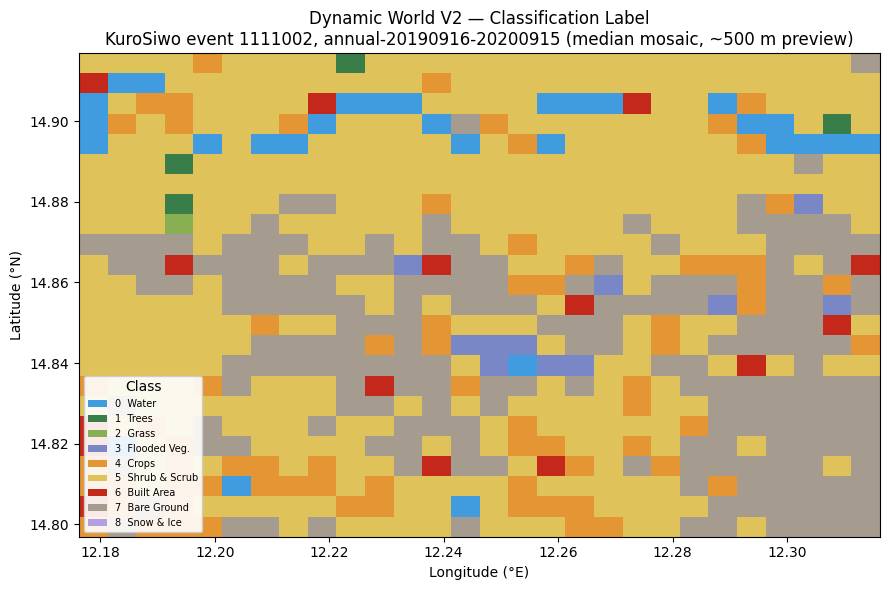

In [7]:
# ── Visualize the classification label map ──────────────────────
DW_COLORS = [
    "#419BDF",  # 0 Water
    "#397D49",  # 1 Trees
    "#88B053",  # 2 Grass
    "#7A87C6",  # 3 Flooded Vegetation
    "#E49635",  # 4 Crops
    "#DFC35A",  # 5 Shrub & Scrub
    "#C4281B",  # 6 Built Area
    "#A59B8F",  # 7 Bare Ground
    "#B39FE1",  # 8 Snow & Ice
]
DW_CLASS_NAMES = [
    "Water", "Trees", "Grass", "Flooded Veg.",
    "Crops", "Shrub & Scrub", "Built Area", "Bare Ground", "Snow & Ice",
]

cmap = mcolors.ListedColormap(DW_COLORS)

fig, ax = plt.subplots(figsize=(9, 6))
da_label.plot(ax=ax, cmap=cmap, vmin=-0.5, vmax=8.5, add_colorbar=False)
ax.set_title(
    "Dynamic World V2 — Classification Label\n"
    f"KuroSiwo event {PREVIEW_EVENT_ID}, {PREVIEW_INTERVAL['label']} "
    "(median mosaic, ~500 m preview)"
)
ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")

legend_handles = [
    Patch(facecolor=DW_COLORS[i], label=f"{i}  {DW_CLASS_NAMES[i]}")
    for i in range(9)
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=7,
          framealpha=0.9, title="Class")
plt.tight_layout()
plt.show()

---
## 2. Transfer to Cloud-Optimized GeoTIFF (COG)

A **Cloud-Optimized GeoTIFF (COG)** stores pixel data in a tile-ordered layout with internal overviews. An HTTP client can fetch only the tiles it needs via **byte-range requests** — without downloading the entire file first.

### Why COG for Dynamic World data?

| Standard GeoTIFF | Cloud-Optimized GeoTIFF |
| :--- | :--- |
| Full download required before read | Any tile readable by HTTP range request |
| No internal overviews | Built-in overviews enable fast zoom-out |
| Needs local filesystem | Compatible with S3, GCS, Azure Blob Storage |
| Not STAC-native | First-class asset type in STAC tooling (stackstac, titiler, rio-tiler) |

### Export workflow

For each month (Jun–Sep 2023) we:
1. Build a **median composite** of all DW images in that month, clipped to the Rotterdam AOI
2. Download via GEE's `getDownloadURL` as a zipped GeoTIFF
3. Re-encode the file with `rasterio` `driver="COG"` (tiled layout + DEFLATE + internal overviews)
4. Store under `output/cogs/`

> **Two assets per month** — the `label` band (uint8 classification index) and the nine `probs` bands (float32 class probabilities) are stored separately so consumers can load only what they need.

In [8]:
# ── Output directories ───────────────────────────────────────────
OUTPUT_DIR = Path("output")
COG_DIR    = OUTPUT_DIR / "cogs"
COG_DIR.mkdir(parents=True, exist_ok=True)

# Band groups
PROB_BANDS  = ["water", "trees", "grass", "flooded_vegetation",
               "crops", "shrub_and_scrub", "built", "bare", "snow_and_ice"]
LABEL_BANDS = ["label"]
LABEL_COLORS_HEX = [
    "#419BDF",  # 0 Water
    "#397D49",  # 1 Trees
    "#88B053",  # 2 Grass
    "#7A87C6",  # 3 Flooded Vegetation
    "#E49635",  # 4 Crops
    "#DFC35A",  # 5 Shrub & Scrub
    "#C4281B",  # 6 Built Area
    "#A59B8F",  # 7 Bare Ground
    "#B39FE1",  # 8 Snow & Ice
]
LABEL_COLORMAP_RGBA = {
    i: tuple(int(LABEL_COLORS_HEX[i][j : j + 2], 16) for j in (1, 3, 5)) + (255,)
    for i in range(len(LABEL_COLORS_HEX))
}

COG_MEDIA_TYPE = "image/tiff; application=geotiff; profile=cloud-optimized"
MAX_BANDS_PER_REQUEST = 1
MAX_DOWNLOAD_RETRIES = 8
SCALE_GROWTH_FACTOR = 1.45


def download_and_save_cog(
    image: ee.Image,
    region: ee.Geometry,
    bands: list,
    output_path: Path,
    scale: float = 0.0003,   # ~30 m per pixel in EPSG:4326 degrees
    crs: str = "EPSG:4326",
) -> Path:
    """
    Download a GEE image tile and write it as a Cloud-Optimized GeoTIFF.

    Large requests are retried automatically with coarser pixel size to reduce
    Earth Engine getPixel/download failures for big AOIs or long time windows.
    """
    ring = ee.Geometry(region).bounds(maxError=1).coordinates().getInfo()[0]
    lons = [pt[0] for pt in ring]
    lats = [pt[1] for pt in ring]

    band_groups = [
        bands[index:index + MAX_BANDS_PER_REQUEST]
        for index in range(0, len(bands), MAX_BANDS_PER_REQUEST)
    ]
    current_scale = float(scale) * max(1.0, np.sqrt(len(bands) / MAX_BANDS_PER_REQUEST))
    last_exc = None

    temp_paths = []
    stacked_path = output_path.with_name(f"{output_path.stem}.stacked.tif")

    for _ in range(MAX_DOWNLOAD_RETRIES):
        for _, part_path in temp_paths:
            part_path.unlink(missing_ok=True)
        temp_paths = []
        stacked_path.unlink(missing_ok=True)

        width = max(1, int(round((max(lons) - min(lons)) / current_scale)))
        height = max(1, int(round((max(lats) - min(lats)) / current_scale)))

        urls = []
        try:
            for band_group in band_groups:
                urls.append((
                    band_group,
                    image.getDownloadURL({
                        "region": [ring],
                        "dimensions": [width, height],
                        "format": "ZIPPED_GEO_TIFF",
                        "crs": crs,
                        "bands": band_group,
                    }),
                ))
        except ee.EEException as exc:
            last_exc = exc
            if "Total request size" in str(exc) or "too large" in str(exc).lower():
                current_scale *= SCALE_GROWTH_FACTOR
                continue
            raise

        try:
            for part_index, (band_group, url) in enumerate(urls):
                response = requests.get(url, stream=True, timeout=600)
                if response.status_code >= 400:
                    message = response.text[:500] if response.text else ""
                    raise requests.HTTPError(
                        f"HTTP {response.status_code} from GEE download. {message}",
                        response=response,
                    )

                part_path = output_path.with_name(f"{output_path.stem}.part{part_index}.tif")
                with zipfile.ZipFile(io.BytesIO(response.content)) as zf:
                    tif_name = next(name for name in zf.namelist() if name.endswith(".tif"))
                    part_path.write_bytes(zf.read(tif_name))
                temp_paths.append((band_group, part_path))

            source_path = temp_paths[0][1]
            if len(temp_paths) > 1:
                with rasterio.open(temp_paths[0][1]) as first_src:
                    profile = first_src.profile.copy()
                    profile.update(count=len(bands))

                    with rasterio.open(stacked_path, "w", **profile) as dst:
                        band_index = 1
                        for band_group, part_path in temp_paths:
                            with rasterio.open(part_path) as src:
                                if (
                                    src.width != first_src.width
                                    or src.height != first_src.height
                                    or src.transform != first_src.transform
                                    or src.crs != first_src.crs
                                ):
                                    raise ValueError(
                                        f"Inconsistent tile metadata while stacking {output_path.name}"
                                    )

                                for source_band_index, band_name in enumerate(band_group, start=1):
                                    dst.write(src.read(source_band_index), band_index)
                                    dst.set_band_description(band_index, band_name)
                                    band_index += 1

                source_path = stacked_path

            if len(bands) == 1 and bands[0] == "label":
                with rasterio.open(source_path, "r+") as raw:
                    raw.write_colormap(1, LABEL_COLORMAP_RGBA)

            with rasterio.open(source_path) as src:
                rio_copy(src, output_path, driver="COG",
                         compress="deflate", overview_resampling="nearest")

            for _, part_path in temp_paths:
                part_path.unlink(missing_ok=True)
            stacked_path.unlink(missing_ok=True)
            return output_path

        except (requests.RequestException, zipfile.BadZipFile, RuntimeError) as exc:
            last_exc = exc
            current_scale *= SCALE_GROWTH_FACTOR
            continue

    for _, part_path in temp_paths:
        part_path.unlink(missing_ok=True)
    stacked_path.unlink(missing_ok=True)
    raise RuntimeError(f"Could not download {output_path.name} after retries: {last_exc}")


rprint(Panel(
    f"[bold]COG output directory:[/bold] {COG_DIR}\n"
    f"[bold]Label bands:[/bold]          {LABEL_BANDS}\n"
    f"[bold]Probability bands:[/bold]    {PROB_BANDS}\n"
    f"[bold]Bands/request:[/bold]        {MAX_BANDS_PER_REQUEST}\n"
    f"[bold]Download retries:[/bold]     {MAX_DOWNLOAD_RETRIES}",
    title="COG Export Config",
    expand=False,
) )

╭─────────────────────────────────────────────── COG Export Config ───────────────────────────────────────────────╮
│ COG output directory: output\cogs                                                                               │
│ Label bands:          ['label']                                                                                 │
│ Probability bands:    ['water', 'trees', 'grass', 'flooded_vegetation', 'crops', 'shrub_and_scrub', 'built',    │
│ 'bare', 'snow_and_ice']                                                                                         │
│ Bands/request:        1                                                                                         │
│ Download retries:     8                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [9]:
# ── Start Dask local cluster + Dashboard ─────────────────────────
import os

try:
    from dask.distributed import Client, LocalCluster
except ImportError as exc:
    raise ImportError(
        "dask.distributed is not installed. Install with: pip install 'dask[distributed]'"
    ) from exc

# Reuse running client if available; otherwise create one with dashboard enabled.
if "client" in globals():
    try:
        client.close()
    except Exception:
        pass

if "cluster" in globals():
    try:
        cluster.close()
    except Exception:
        pass

cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=4,
    processes=False,
    protocol="tcp",
    host="127.0.0.1",
    dashboard_address=":0",  # random available port
)
client = Client(cluster)

dashboard_link = client.dashboard_link

if "rprint" in globals() and "Panel" in globals():
    rprint(
        Panel(
            f"[bold]Dask workers:[/bold] 4\n"
            f"[bold]Threads/worker:[/bold] 4\n"
            f"[bold]Dashboard (random port):[/bold] {dashboard_link}",
            title="Dask Dashboard",
            expand=False,
        )
    )
else:
    print("Dask workers: 4")
    print("Threads/worker: 4")
    print("Dashboard (random port):", dashboard_link)

client

╭──────────────────── Dask Dashboard ────────────────────╮
│ Dask workers: 4                                        │
│ Threads/worker: 4                                      │
│ Dashboard (random port): http://127.0.0.1:62672/status │
╰────────────────────────────────────────────────────────╯

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:62672/status,
Dashboard: http://127.0.0.1:62672/status,Workers: 4
Total threads: 16,Total memory: 31.21 GiB
Status: running,Using processes: False
Comm: tcp://127.0.0.1:62673,Workers: 0
Dashboard: http://127.0.0.1:62672/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:62112,Total threads: 4
Dashboard: http://127.0.0.1:62113/status,Memory: 7.80 GiB
Nanny: None,


In [10]:
# ── Export one COG pair per event annual interval (Dask parallel) ──
from collections import Counter
import re
import time
import uuid

from rich.progress import (
    BarColumn,
    Progress,
    TaskProgressColumn,
    TextColumn,
    TimeElapsedColumn,
    TimeRemainingColumn,
)

# ── Test controls ───────────────────────────────────────────────────
RUN_PRECHECK_TESTS = True
DRY_RUN_N_TASKS = 0

# ── Stability / watchdog controls ──────────────────────────────────
MAX_IDLE_SECONDS = 0  # 0 disables idle watchdog
TASK_RESULT_TIMEOUT = 10
MAX_TASK_WALL_SECONDS = 0  # 0 disables per-task wall timeout

if "client" not in globals():
    raise RuntimeError("Dask client is not initialized. Run Cell 13 first.")

if getattr(client, "status", "closed") != "running":
    raise RuntimeError("Dask client is not running. Re-run Cell 13.")


def _dask_ping(value: int) -> int:
    return value + 1


def _ensure_ee_initialized(service_account: str, key_path: str) -> None:
    is_initialized = False
    if hasattr(ee.data, "is_initialized"):
        is_initialized = bool(ee.data.is_initialized())
    elif hasattr(ee.data, "_initialized"):
        is_initialized = bool(getattr(ee.data, "_initialized"))

    if not is_initialized:
        creds = ee.ServiceAccountCredentials(service_account, key_path)
        ee.Initialize(creds)


if RUN_PRECHECK_TESTS:
    scheduler_info = client.scheduler_info()
    worker_count = len(scheduler_info.get("workers", {}))
    if worker_count == 0:
        raise RuntimeError("Precheck failed: no active Dask workers.")

    ping_result = client.submit(_dask_ping, 1, pure=False).result(timeout=10)
    if ping_result != 2:
        raise RuntimeError(f"Precheck failed: unexpected Dask ping result {ping_result}")

    rprint(
        Panel(
            f"[green]Precheck passed[/green]\n"
            f"[bold]Workers:[/bold] {worker_count}\n"
            f"[bold]Dashboard:[/bold] {client.dashboard_link}",
            title="Dask Export Precheck",
            expand=False,
        )
    )

exported_cogs: dict[str, dict] = {}
skipped_intervals: list[str] = []
failed_intervals: list[str] = []

tasks: list[dict] = []

for event_id, event in EVENTS.items():
    safe_event_id = re.sub(r"[^0-9A-Za-z_]+", "_", event_id)

    for interval in event["intervals"]:
        stem = f"dw_kurosiwo_{event_id}_{interval['label']}"
        label_path = COG_DIR / f"{stem}_label.tif"
        probs_path = COG_DIR / f"{stem}_probs.tif"
        item_key = f"{event_id}-{interval['label']}"

        exported_cogs[item_key] = {
            "item_id": f"dw-kurosiwo-{event_id}-{interval['label']}",
            "event_id": event_id,
            "interval_label": interval["label"],
            "start_datetime": interval["start_datetime"].to_pydatetime(),
            "end_datetime": interval["end_datetime"].to_pydatetime(),
            "label_path": label_path,
            "probs_path": probs_path,
            "image_count": 0,
        }

        if label_path.exists() and probs_path.exists():
            continue

        tasks.append({
            "event_id": event_id,
            "event_task_group": f"event_{safe_event_id}",
            "interval_label": interval["label"],
            "start": interval["start"],
            "end": interval["end"],
            "label_path": str(label_path),
            "probs_path": str(probs_path),
            "item_key": item_key,
        })


def _export_interval(
    event_id: str,
    start: str,
    end: str,
    label_path_str: str,
    probs_path_str: str,
    service_account: str,
    key_path: str,
) -> dict:
    _ensure_ee_initialized(service_account, key_path)

    label_path = Path(label_path_str)
    probs_path = Path(probs_path_str)

    event = EVENTS[event_id]
    interval_collection = build_dw_collection(event, start, end)
    interval_count = int(interval_collection.size().getInfo())
    if interval_count == 0:
        return {
            "event_id": event_id,
            "label_path": label_path_str,
            "probs_path": probs_path_str,
            "image_count": 0,
            "skipped": True,
            "reason": "no_dw_scenes_in_annual_window",
        }

    probs_mosaic = interval_collection.select(PROB_BANDS).median().clip(event["geometry"])

    label_mode = interval_collection.select("label").mode().toByte().clip(event["geometry"])
    label_from_probs = (
        probs_mosaic.toArray()
        .arrayArgmax()
        .arrayGet([0])
        .toByte()
        .rename("label")
    )
    label_mosaic = label_mode.unmask(label_from_probs).unmask(0).toByte().rename("label")

    # Annual composites need coarser defaults to avoid oversized direct-download requests.
    bbox = event["bbox"]
    lon_span = max(0.0, float(bbox[2]) - float(bbox[0]))
    lat_span = max(0.0, float(bbox[3]) - float(bbox[1]))
    bbox_area_deg2 = lon_span * lat_span
    if bbox_area_deg2 > 6.0:
        export_scale = 0.0024
    elif bbox_area_deg2 > 3.0:
        export_scale = 0.0018
    elif bbox_area_deg2 > 1.0:
        export_scale = 0.0012
    elif bbox_area_deg2 > 0.4:
        export_scale = 0.0009
    else:
        export_scale = 0.0006

    if not label_path.exists():
        download_and_save_cog(label_mosaic, event["geometry"], LABEL_BANDS, label_path, scale=export_scale)

    if not probs_path.exists():
        download_and_save_cog(probs_mosaic, event["geometry"], PROB_BANDS, probs_path, scale=export_scale)

    return {
        "event_id": event_id,
        "label_path": label_path_str,
        "probs_path": probs_path_str,
        "image_count": interval_count,
        "skipped": False,
    }


if tasks:
    if DRY_RUN_N_TASKS > 0:
        tasks = sorted(tasks, key=lambda t: (t["event_id"], t["interval_label"]))
        tasks = tasks[: min(DRY_RUN_N_TASKS, len(tasks))]
        allowed_item_keys = {task["item_key"] for task in tasks}
        exported_cogs = {k: v for k, v in exported_cogs.items() if k in allowed_item_keys}

    worker_count = len(client.scheduler_info().get("workers", {}))
    if worker_count == 0:
        raise RuntimeError("No active Dask workers. Re-run Cell 13 to start the cluster.")

    per_event_counts = Counter(task["event_id"] for task in tasks)
    top_events = ", ".join(
        f"{event_id}:{count}" for event_id, count in per_event_counts.most_common(8)
    )

    run_mode = "DRY RUN" if DRY_RUN_N_TASKS > 0 else "FULL RUN"
    rprint(
        Panel(
            f"[bold]Mode:[/bold] {run_mode}\n"
            f"[bold]Tasks to export:[/bold] {len(tasks)}\n"
            f"[bold]Dask workers:[/bold] {worker_count}\n"
            f"[bold]Dashboard:[/bold] {client.dashboard_link}\n"
            f"[bold]Task groups (top):[/bold] {top_events}",
            title="Dask Export Plan (Annual)",
            expand=False,
        )
    )

    future_to_task = {}
    future_start_ts = {}
    for task in tasks:
        key = f"{task['event_task_group']}-{task['interval_label']}-{uuid.uuid4().hex[:8]}"
        future = client.submit(
            _export_interval,
            task["event_id"],
            task["start"],
            task["end"],
            task["label_path"],
            task["probs_path"],
            SERVICE_ACCOUNT,
            KEY_PATH,
            key=key,
            pure=False,
            retries=1,
        )
        future_to_task[future] = task
        future_start_ts[future] = time.perf_counter()

    total = len(tasks)
    completed = 0
    t0 = time.perf_counter()
    last_completion_ts = t0

    pending = set(future_to_task.keys())

    with Progress(
        TextColumn("[progress.description]{task.description}"),
        BarColumn(bar_width=40),
        TaskProgressColumn(),
        TimeElapsedColumn(),
        TimeRemainingColumn(),
        transient=False,
    ) as progress:
        progress_task = progress.add_task("Exporting annual event COGs", total=total)

        while pending:
            finished_now = [future for future in list(pending) if future.done()]

            for future in finished_now:
                pending.remove(future)
                src_task = future_to_task[future]
                event_id = src_task["event_id"]
                interval_label = src_task["interval_label"]

                try:
                    done = future.result(timeout=TASK_RESULT_TIMEOUT)
                    if done.get("skipped", False):
                        skipped_intervals.append(f"{event_id}:{interval_label}")
                        exported_cogs.pop(src_task["item_key"], None)
                        last_completion_ts = time.perf_counter()
                        reason = done.get("reason", "no_images")
                        rprint(f"  [yellow]-[/yellow] event {event_id} / {interval_label} skipped ({reason})")
                        continue

                    lp = Path(done["label_path"])
                    pp = Path(done["probs_path"])
                    exported_cogs[src_task["item_key"]]["image_count"] = int(done.get("image_count", 0))
                    last_completion_ts = time.perf_counter()
                    rprint(
                        f"  [green]✓[/green] event {event_id} / {interval_label}  ->  "
                        f"label: {lp.stat().st_size / 1024:.0f} KB  |  "
                        f"probs: {pp.stat().st_size / 1024:.0f} KB"
                    )
                except Exception as exc:
                    last_completion_ts = time.perf_counter()
                    failed_intervals.append(f"{event_id}:{interval_label} ({exc})")
                    exported_cogs.pop(src_task["item_key"], None)
                    rprint(f"  [red]✗[/red] event {event_id} / {interval_label} failed: {exc}")

            completed = total - len(pending)
            elapsed = max(time.perf_counter() - t0, 1e-6)
            rate = completed / elapsed
            eta_seconds = (total - completed) / rate if rate > 0 else float("inf")
            eta_text = f"{eta_seconds / 60:.1f} min" if completed > 0 else "--"

            pending_count = len([f for f in pending if f.status == "pending"])
            running_count = len(pending) - pending_count

            progress.update(
                progress_task,
                completed=completed,
                description=(
                    f"Exporting ({completed}/{total}, {completed / total * 100:.1f}%, "
                    f"ETA {eta_text}, running {running_count}, pending {pending_count})"
                ),
            )

            now = time.perf_counter()
            timed_out_futures = []
            if MAX_TASK_WALL_SECONDS > 0:
                timed_out_futures = [
                    future
                    for future in list(pending)
                    if (now - future_start_ts.get(future, now)) > MAX_TASK_WALL_SECONDS
                ]
            for future in timed_out_futures:
                pending.remove(future)
                future.cancel()
                src_task = future_to_task[future]
                event_id = src_task["event_id"]
                interval_label = src_task["interval_label"]
                failed_intervals.append(
                    f"{event_id}:{interval_label} (task wall timeout > {MAX_TASK_WALL_SECONDS}s)"
                )
                exported_cogs.pop(src_task["item_key"], None)
                last_completion_ts = now
                rprint(
                    f"  [red]✗[/red] event {event_id} / {interval_label} timed out after "
                    f"{MAX_TASK_WALL_SECONDS // 60} min"
                )

            if MAX_IDLE_SECONDS > 0 and completed < total and (now - last_completion_ts) > MAX_IDLE_SECONDS:
                for future in list(pending):
                    future.cancel()
                raise TimeoutError(
                    "No task completed within MAX_IDLE_SECONDS. "
                    "Check internet/EE quota and retry with smaller DRY_RUN_N_TASKS."
                )

            if pending:
                time.sleep(0.5)

rprint(
    Panel(
        f"[green]Ready {len(exported_cogs)} annual event COG pairs[/green]\n"
        f"[bold]Skipped empty intervals:[/bold] {len(skipped_intervals)}\n"
        f"[bold]Failed exports:[/bold] {len(failed_intervals)}",
        expand=False,
    )
)

if failed_intervals:
    rprint(Panel("\n".join(failed_intervals), title="[red]Failed intervals[/red]", expand=False))

if DRY_RUN_N_TASKS > 0 and len(exported_cogs) == 0 and len(failed_intervals) == 0:
    rprint(
        Panel(
            "Dry run tasks were all skipped (no images found in sampled intervals).\n"
            "Try increasing DRY_RUN_N_TASKS (e.g., 20) or run full mode with DRY_RUN_N_TASKS = 0.",
            title="[yellow]Dry Run Note[/yellow]",
            expand=False,
        )
    )

╭────────── Dask Export Precheck ──────────╮
│ Precheck passed                          │
│ Workers: 4                               │
│ Dashboard: http://127.0.0.1:62672/status │
╰──────────────────────────────────────────╯

╭─────────────────────────────────╮
│ Ready 42 annual event COG pairs │
│ Skipped empty intervals: 0      │
│ Failed exports: 0               │
╰─────────────────────────────────╯

In [11]:
# ── Define exact bounding box and time range from the exported COGs ──
first_label = next(iter(exported_cogs.values()))["label_path"]
da_verify   = rioxarray.open_rasterio(first_label)

spatial_bounds = []
for paths in exported_cogs.values():
    da_bounds = rioxarray.open_rasterio(paths["label_path"])
    spatial_bounds.append([
        float(da_bounds.x.min()),
        float(da_bounds.y.min()),
        float(da_bounds.x.max()),
        float(da_bounds.y.max()),
    ])
    da_bounds.close()

BBOX = [
    min(bounds[0] for bounds in spatial_bounds),
    min(bounds[1] for bounds in spatial_bounds),
    max(bounds[2] for bounds in spatial_bounds),
    max(bounds[3] for bounds in spatial_bounds),
]
TEMPORAL_START = min(paths["start_datetime"] for paths in exported_cogs.values())
TEMPORAL_END   = max(paths["end_datetime"] for paths in exported_cogs.values())

res_x, res_y = da_verify.rio.resolution()

rprint(Panel(
    f"[bold]Reference CRS:[/bold]      {da_verify.rio.crs}\n"
    f"[bold]Reference shape:[/bold]    {list(da_verify.shape)}  (bands × rows × cols)\n"
    f"[bold]Pixel size:[/bold]         {abs(res_x):.6f}° × {abs(res_y):.6f}°  (~{abs(res_x)*111_000:.0f} m)\n"
    f"\n"
    f"[bold]Combined bounding box:[/bold]\n"
    f"  West  : {BBOX[0]:.6f}°E\n"
    f"  East  : {BBOX[2]:.6f}°E\n"
    f"  South : {BBOX[1]:.6f}°N\n"
    f"  North : {BBOX[3]:.6f}°N\n"
    f"\n"
    f"[bold]Temporal extent:[/bold]\n"
    f"  Start : {TEMPORAL_START.isoformat()}\n"
    f"  End   : {TEMPORAL_END.isoformat()}",
    title="[bold]Exact Spatial & Temporal Extent[/bold]",
    expand=False,
))

da_verify.close()

╭──────────── Exact Spatial & Temporal Extent ─────────────╮
│ Reference CRS:      EPSG:4326                            │
│ Reference shape:    [1, 230, 202]  (bands × rows × cols) │
│ Pixel size:         0.000599° × 0.000600°  (~67 m)       │
│                                                          │
│ Combined bounding box:                                   │
│   West  : -97.267676°E                                   │
│   East  : 153.373512°E                                   │
│   South : -33.809730°N                                   │
│   North : 59.312336°N                                    │
│                                                          │
│ Temporal extent:                                         │
│   Start : 2015-06-27T00:00:00+00:00                      │
│   End   : 2022-09-11T23:59:59+00:00                      │
╰──────────────────────────────────────────────────────────╯